# Notebook 03: Earthquake catalogs and picks

**Goal (about 1.5 hours):** understand the tables that describe earthquakes (a *catalog*) and arrival times (*picks*), map the July 2025 swarm, and see where the measurements you will make come from.

Background reading (20 minutes): PNSN's [Mount Rainier page](https://pnsn.org/volcanoes/mount-rainier) has a short section on the July 2025 swarm. For the vocabulary of events and picks see Seismo-Live's [05 Event metadata](https://seismo-live.github.io/html/ObsPy/05_Event_metadata_wrapper.html) (Krischer, CC BY-NC-SA 4.0).

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


## 1. The event catalog

An earthquake catalog is a table: one row per earthquake with origin time, latitude, longitude, depth and magnitude. Ours is a PNSN export for the Rainier area. The locations were computed by PNSN from arrival times and a simple layered velocity model; they carry errors of hundreds of metres to a few km, which we will come back to.

In [2]:
ev = data.load_events()
print(len(ev), "events;", ev.time.min().date(), "to", ev.time.max().date())
ev[["evid", "time", "lat", "lon", "depth", "magnitude"]].head()

1378 events; 2025-07-08 to 2025-08-29


,evid,time,lat,lon,depth,magnitude
0,62134047,2025-07-08 02:57:36.649997711+00:00,46.846500,-121.770167,-1.85,0.46
1,62134077,2025-07-08 05:14:01.960000038+00:00,46.849500,-121.761500,-1.02,0.34
2,62134102,2025-07-08 08:39:50.009998322+00:00,46.851333,-121.762000,-0.33,0.28
3,61504508,2025-07-08 08:40:21.079999924+00:00,46.853000,-121.764500,0.52,0.02
4,62134107,2025-07-08 08:45:38.549999237+00:00,46.850167,-121.759333,-0.28,1.46


Depth convention (easy to get wrong): kilometres **relative to sea level, positive down**. Rainier's summit is 4.39 km above sea level, so an earthquake 1 km below the summit has depth about -3.4. Negative depths are normal here.

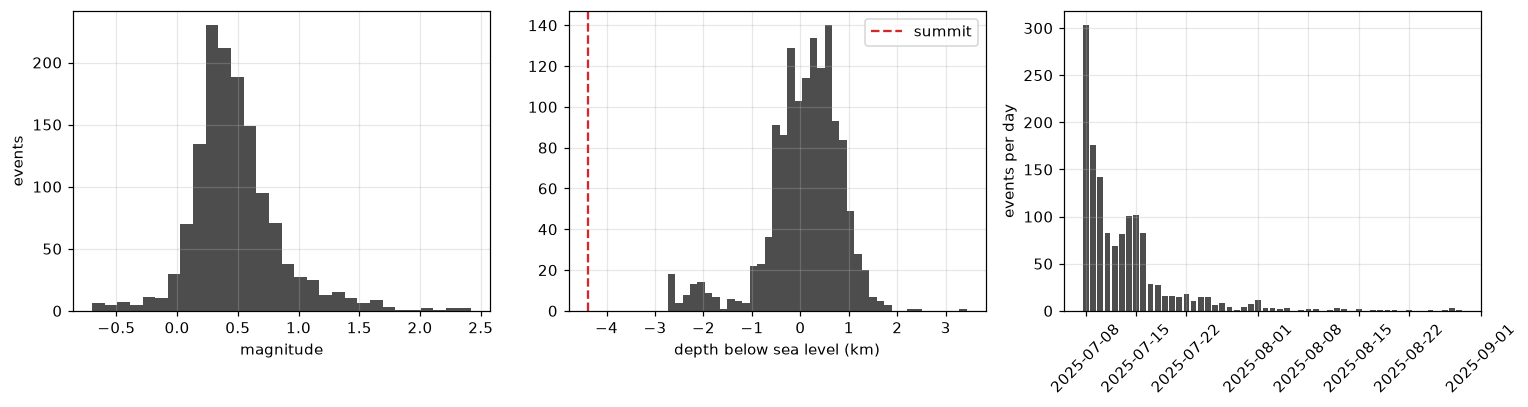

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(ev.magnitude.dropna(), bins=30, color="0.3"); axes[0].set_xlabel("magnitude"); axes[0].set_ylabel("events")
axes[1].hist(ev.depth, bins=40, color="0.3"); axes[1].set_xlabel("depth below sea level (km)")
axes[1].axvline(-4.392, color="tab:red", ls="--", label="summit"); axes[1].legend()
daily = ev.set_index("time").resample("D").size()
axes[2].bar(daily.index, daily.values, color="0.3"); axes[2].set_ylabel("events per day")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()

Three things the histograms tell you: most events are tiny (magnitude below 1; a magnitude-0 earthquake releases about as much energy as a hand grenade), they are shallow and clustered near the summit, and the whole swarm happens in about two weeks starting July 8, 2025 with most of it in the first few days.

## 2. Map it

A map is just a scatter plot of longitude against latitude. One subtlety: a degree of longitude is shorter than a degree of latitude at 47 N by a factor cos(47 deg) about 0.68, so we set the aspect ratio to keep distances honest. Stations are drawn as triangles, the convention in seismology.

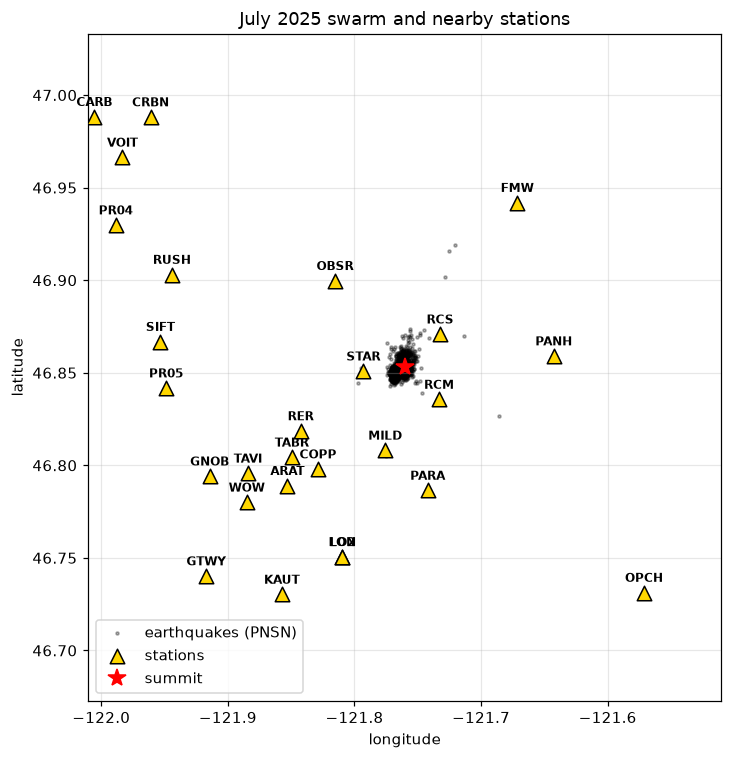

In [4]:
sta = data.load_stations()
summit = (46.8529, -121.7604)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ev.lon, ev.lat, s=4, c="k", alpha=0.3, label="earthquakes (PNSN)")
ax.scatter(sta.lon, sta.lat, marker="^", s=90, c="#FFD700", edgecolor="k", zorder=5, label="stations")
for _, s in sta.iterrows():
    ax.annotate(s.station, (s.lon, s.lat), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8, weight="bold")
ax.plot(*summit[::-1], "r*", ms=12, label="summit")
ax.set_xlim(summit[1] - 0.25, summit[1] + 0.25); ax.set_ylim(summit[0] - 0.18, summit[0] + 0.18)
ax.set_aspect(1 / np.cos(np.deg2rad(summit[0])))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="lower left")
ax.set_title("July 2025 swarm and nearby stations")
plt.tight_layout()

Zoom in on the summit (change the limits to plus or minus 0.05 degrees) and you will see the swarm is a tight cloud a few km across, just west of the summit. STAR sits on the summit itself; RCM and MILD a few km away. Stations further out see the swarm at a shallower angle, which matters a lot for splitting, as notebook 05 explains.

## 3. Picks

A **pick** is the time an analyst (or an algorithm) marked a wave arrival on one station's record. The catalog we use for splitting is a table of (earthquake, station) pairs that have **both** a P and an S pick, each with a quality score from 0 to 1. The `_strict` catalog keeps only pairs where both scores are at least 0.75. That is the first filtering decision in the whole project and it is worth remembering: *we only ever measure earthquakes that a human was confident about.*

In [5]:
cat = data.load_station_catalog("STAR")
print(len(cat), "earthquake-station pairs at STAR with reviewed P and S picks")
cat[["evid", "origin_time", "p_time", "p_quality", "s_time", "s_quality", "event_magnitude", "event_depth"]].head()

1196 earthquake-station pairs at STAR with reviewed P and S picks


,evid,origin_time,p_time,p_quality,s_time,s_quality,event_magnitude,event_depth
0,61504363,2025-07-08 15:24:37.709999084+00:00,2025-07-08 15:24:38.421168804+00:00,1.0,2025-07-08 15:24:38.989881754+00:00,1.00,-0.44,0.45
1,61504373,2025-07-08 15:38:45.819999695+00:00,2025-07-08 15:38:46.439848900+00:00,1.0,2025-07-08 15:38:47.008554220+00:00,0.75,0.31,0.03
2,61504388,2025-07-08 15:47:51.469997406+00:00,2025-07-08 15:47:52.119999886+00:00,1.0,2025-07-08 15:47:52.719038963+00:00,1.00,0.36,0.26
3,61504393,2025-07-08 15:50:27.059999704+00:00,2025-07-08 15:50:27.759302855+00:00,1.0,2025-07-08 15:50:28.331223011+00:00,0.75,-0.53,0.13
4,61504398,2025-07-08 15:50:56.389999390+00:00,2025-07-08 15:50:57.039684772+00:00,1.0,2025-07-08 15:50:57.589113712+00:00,0.75,-0.08,-0.26


median S-P at STAR: 0.60 s


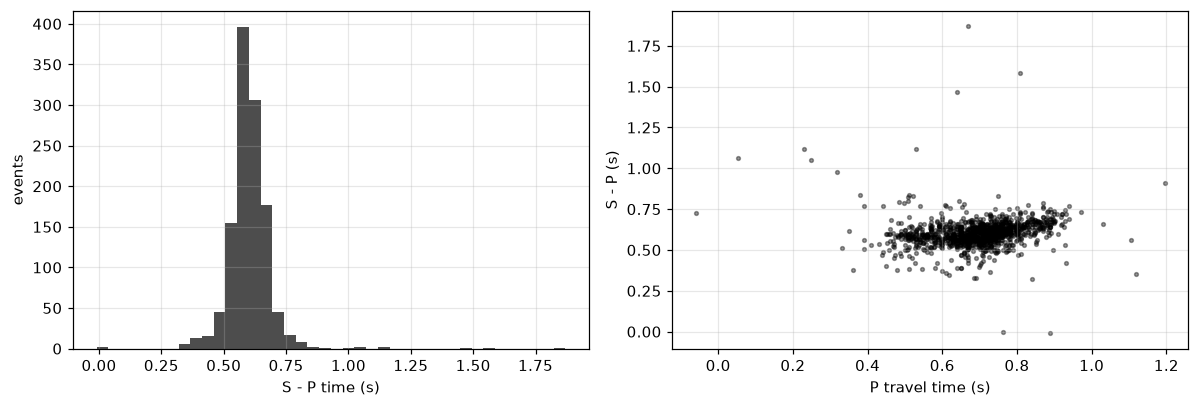

In [6]:
cat["sp_s"] = (cat.s_time - cat.p_time).dt.total_seconds()
cat["p_minus_origin"] = (cat.p_time - cat.origin_time).dt.total_seconds()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(cat.sp_s, bins=40, color="0.3"); axes[0].set_xlabel("S - P time (s)"); axes[0].set_ylabel("events")
axes[1].scatter(cat.p_minus_origin, cat.sp_s, s=6, c="k", alpha=0.4)
axes[1].set_xlabel("P travel time (s)"); axes[1].set_ylabel("S - P (s)")
plt.tight_layout()
print(f"median S-P at STAR: {cat.sp_s.median():.2f} s")

The S-P times cluster around 0.6 s: these earthquakes are a few km from STAR. The right panel should be close to a straight line: S-P equals P travel time times (Vp/Vs - 1), so its slope is a crude estimate of the velocity ratio. Scatter off the line is pick error plus location error plus real structure. Hold that thought for the uncertainty notebooks.

## 4. Geometry: back azimuth and distance

For each (earthquake, station) pair we need the **back azimuth**, the compass direction from the station to the earthquake, and the distance. ObsPy's `gps2dist_azimuth` does the spherical geometry.

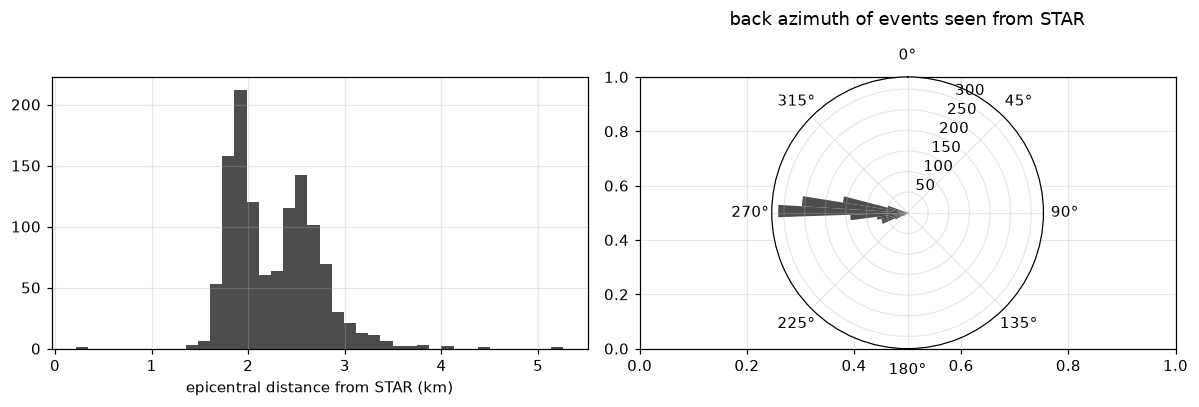

In [7]:
from obspy.geodetics import gps2dist_azimuth
lat, lon, elev = data.station_coords("STAR")
geo = [gps2dist_azimuth(lat, lon, r.event_lat, r.event_lon) for _, r in cat.iterrows()]
cat["dist_km"] = [g[0] / 1000 for g in geo]
cat["baz"] = [g[2] for g in geo]       # azimuth from station to event
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(cat.dist_km, bins=40, color="0.3"); axes[0].set_xlabel("epicentral distance from STAR (km)")
ax = plt.subplot(1, 2, 2, projection="polar"); ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.hist(np.deg2rad(cat.baz), bins=36, color="0.3"); ax.set_title("back azimuth of events seen from STAR", pad=15)
plt.tight_layout()

Almost everything arrives from one narrow range of back azimuths (the swarm is small and sits in one direction). That is important and slightly unfortunate: with all rays coming from the same direction we cannot separate "the rock is anisotropic" from "something about this one ray path"; stations with a spread of back azimuths are more convincing. Notebook 08 returns to this.

## 5. Exercises

1. Make the map again with the point colour set by origin day (`ev.time.dt.dayofyear`). Does the swarm move with time?
2. Fit a straight line to the P-travel-time versus S-P plot (`np.polyfit`) and estimate Vp/Vs. Compare with the 1.73 assumed in the research repo's velocity model.
3. Plot distance against S-P time with a 1:8 reference line. Which events are far from the line, and what could be wrong with them?
4. Repeat section 4 for RCM (`data.load_station_catalog("RCM")`; its waveforms are not cached, but the picks are in `data/catalog/rainier_catalog_strict.csv`, filter it by station). Is the back-azimuth distribution wider?

Next: `04_filtering_spectra_snr.ipynb`.